In [2]:
###############################################################################
# HPC Job Configuration
###############################################################################
# Request HPC resources: 1 node, 64 tasks, 8 hours runtime
# srun -p RM-shared -N 1 --ntasks-per-node=64 -t 8:00:00 --pty /bin/bash

###############################################################################
# Load Required Libraries
###############################################################################
library(ArchR)          # Framework for single-cell ATAC-seq analysis
library(BSgenome.Hsapiens.UCSC.hg38)
library(tidyverse)      # Collection of data manipulation packages
library(dplyr)
library(here)           # Project-relative file path management
library(limma)          # Differential expression analysis
library(edgeR)          # Normalization of count data
library(swfdr)          # Multiple testing correction
library(rtracklayer)    # For reading and writing genomic data

###############################################################################
# Initial Data Processing and Cell Classification
###############################################################################
# Configure ArchR settings for parallel processing
#n_cores = Sys.getenv("SLURM_NTASKS_PER_NODE") %>% as.numeric()
n_cores = parallel::detectCores() %>% as.numeric()
addArchRThreads(threads = n_cores / 4 %>% round())

# Set up output directories
DATADIR='/Aging/Data/Anderson/Multiomics/ATAC/ArchR/'
PLOTDIR='/Aging/Aging_Clock/Plots/'
setwd(DATADIR)

# Define pre-seq variables
DIST_TO_TSS <- 10 * 10^3 # how far from TSS to annotate peak as "promoter"

dir.create(here(DATADIR, 'peaks'), showWarnings = F, recursive = T)
dir.create(here(DATADIR, 'rdas'), showWarnings = F, recursive = T)
dir.create(here(DATADIR, 'tables'), showWarnings = F, recursive = T)

#------------------------------------------------------------------------------
# Helper Functions
#------------------------------------------------------------------------------
# String splitting utility
ss <- function(x, pattern, slot = 1, ...) {
  sapply(strsplit(x = x, split = pattern, ...), "[", slot)
}

# for narrowPeak r function utilities
#source(here('code/final_code/hal_scripts/narrowPeakFunctions.R'))
source('/singleCell/Stauffer_macaque_multiome_VentralPutamen/code/ldsc_multiomeATAC_Striatum/narrowPeakFunctions.R')
# this is a published R function that we will use for limma-voom DEA
source("https://github.com/YOU-k/voomByGroup/raw/main/voomByGroup.R")


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [80]:
# Intrinsic / Systemic
# AD / Ctrl
# Exc / Inh

diff_results_file = 
paste0('Anderson_PFC_AD_Inh_neg0_diffPeakList_byModel.rds') %>% here(DATADIR, 'rdas', .)
df_res_neg0 <- readRDS(diff_results_file) %>% bind_rows()
diff_results_file = 
paste0('Anderson_PFC_AD_Inh_neg24_diffPeakList_byModel.rds') %>% here(DATADIR, 'rdas', .)
df_res_neg24 <- readRDS(diff_results_file) %>% bind_rows()
#-----------------------------------------------------------
#-----------------------------------------------------------

quantile=quantile(df_res_neg24$logFC,0.98)

df_res_neg24 <- df_res_neg24 %>%
filter(logFC > quantile) %>% 
  mutate(
    adj.P.Val = p.adjust(P.Value, method = "BH"),
    adj.P.Val.SWFDR = lm_qvalue(P.Value, X = AveExpr)$q
  ) %>%
  filter(
    adj.P.Val.SWFDR < 0.05
  )
#-----------------------------------------------------------
#-----------------------------------------------------------

quantile=quantile(df_res_neg0$logFC,0.98)

df_res_neg0 <- df_res_neg0 %>%
filter(logFC > quantile) %>% 
  mutate(
    adj.P.Val = p.adjust(P.Value, method = "BH"),
    adj.P.Val.SWFDR = lm_qvalue(P.Value, X = AveExpr)$q
  ) %>%
  filter(
    adj.P.Val.SWFDR < 0.05
  )

#-----------------------------------------------------------
#-----------------------------------------------------------
diff_bed <- tibble(raw = df_res_neg24$peak) %>%
    tidyr::separate(raw, into = c('prefix','chr','coord','width'), sep=':') %>%
    tidyr::separate(coord, into = c('start','end'), sep='-') %>%
    mutate(
        start = as.integer(start),
        end = as.integer(end),
        width = as.integer(width)
    ) %>%
    select(chr, start, end)
write.table(diff_bed, quote=F, row.names=F, col.names=F, sep = "\t",
            here(DATADIR, 'peaks', paste0('Anderson_PFC_AD_Inh_peaks_neg24_vs_all.diff_up_logFC_0.98.bed')))

diff_bed <- tibble(raw = df_res_neg0$peak) %>%
    tidyr::separate(raw, into = c('prefix','chr','coord','width'), sep=':') %>%
    tidyr::separate(coord, into = c('start','end'), sep='-') %>%
    mutate(
        start = as.integer(start),
        end = as.integer(end),
        width = as.integer(width)
    ) %>%
    select(chr, start, end)
write.table(diff_bed, quote=F, row.names=F, col.names=F, sep = "\t",
            here(DATADIR, 'peaks', paste0('Anderson_PFC_AD_Inh_peaks_neg0_vs_all.diff_up_logFC_0.98.bed')))

Warning message:
“There were 20 warnings in `mutate()`.
The first warning was:
ℹ In argument: `adj.P.Val.SWFDR = lm_qvalue(P.Value, X = AveExpr)$q`.
Caused by warning:
! maximal p is smaller than maximal lambda
ℹ Run `dplyr::last_dplyr_warnings()` to see the 19 remaining warnings.”
Warning message:
“There were 18 warnings in `mutate()`.
The first warning was:
ℹ In argument: `adj.P.Val.SWFDR = lm_qvalue(P.Value, X = AveExpr)$q`.
Caused by warning:
! maximal p is smaller than maximal lambda
ℹ Run `dplyr::last_dplyr_warnings()` to see the 17 remaining warnings.”


In [8]:
df_res_neg24 <- df_res_neg24[c('model','peak','logFC','AveExpr','P.Value','adj.P.Val.SWFDR')]
write.csv(df_res_neg24, paste0(DATADIR,'peaks/Anderson_PFC_AD_Inh_neg24_diffPeakList_up.csv'))

** Motif Enrichment **

In [ ]:
# TF Enrichment -- HOMER

# Homer command
#findMotifsGenome.pl /Aging/Data/Anderson/Multiomics/ATAC/ArchR/peaks/Anderson_PFC_AD_Inh_peaks_neg24_vs_all.diff_up_logFC_0.98.bed hg38 /Aging/Data/Anderson/Multiomics/ATAC/ArchR/peaks/Homer_Motif -size 500 -mask
#findMotifsGenome.pl /Aging/LQ_TACIT/aging_model/aging_pos_longevity_neg_intersect.bed hg38 /Aging/Data/Anderson/Multiomics/ATAC/ArchR/peaks/Homer_Motif_overlap/ -size 500 -mask

homer = read.csv(paste0(DATADIR,'peaks/Homer_Motif/knownResults.txt'), sep = "\t")
homer = homer[homer$P.value < 10^-30,]

homer = homer %>%
  rename(
    motif = 'Motif.Name',
    pval = 'P.value',
    logP = 'Log.P.value',
    pct_targets = 'X..of.Target.Sequences.with.Motif',
    pct_bg = 'X..of.Background.Sequences.with.Motif'
  ) %>%
  mutate(
    motif = sub("[--]ChIP-Seq.*$","",motif),
    neg_logP = as.numeric(logP)*(-1),
    pct_targets = as.numeric(gsub("%", "", pct_targets)),
    pct_bg = as.numeric(gsub("%", "", pct_bg))
  )
homer

#---------------------------------------------------------------------------------------------

# Manuscript Figure 7I --------------------------------------------------------
#------------------------------------------------------------------------------

pdf(paste0(PLOTDIR, 'Anderson_AD_Inh_Neg24_homer_knownResults.pdf'), width = 10, height = 10)

ggplot(homer, aes(x = reorder(motif, neg_logP), y = neg_logP)) +
  geom_col(fill = "#001F3F") +
  coord_flip() +
  labs(
    x = NULL,
    y = "-log10(P-value)",
    title = "Top Enriched Motifs (HOMER)"
  ) +
  theme_classic(base_size = 14)


ggplot(homer,
       aes(x = reorder(motif, neg_logP),
           y = pct_targets - pct_bg,
           size = neg_logP)) +
  geom_point(alpha = 0.7, color = "#001F3F") +
  coord_flip() +
  labs(
    x = NULL,
    y = "Δ % (Targets − Background)",
    size = "-log10(P)",
    title = "Motif Enrichment Effect Size"
  ) +
  theme_classic(base_size = 20)

ggplot(homer,
       aes(x = pct_bg, y = pct_targets, label = motif)) +
  geom_point(size = 3, color = "#DC2626") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggrepel::geom_text_repel(size = 3) +
  labs(
    x = "% Background Peaks",
    y = "% Target Peaks",
    title = "Motif Enrichment: Targets vs Background"
  ) +
  theme_classic(base_size = 20)

dev.off()

,motif,Consensus,pval,logP,q.value..Benjamini.,X..of.Target.Sequences.with.Motif.of.408.,pct_targets,X..of.Background.Sequences.with.Motif.of.97968.,pct_bg,neg_logP
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,CTCF(Zf)/CD4+-CTCF,AYAGTGCCMYCTRGTGGCCA,1e-66,-152.40,0,95,23.28,2125.9,2.17,152.40
2,BORIS(Zf)/K562-CTCFL,CNNBRGCGCCCCCTGSTGGC,1e-44,-102.50,0,94,23.04,3715.0,3.79,102.50
3,Ap4(bHLH)/AML-Tfap4,NAHCAGCTGD,1e-15,-35.77,0,179,43.87,24784.7,25.29,35.77
4,Tcf21(bHLH)/ArterySmoothMuscle-Tcf21,NAACAGCTGG,1e-14,-33.65,0,152,37.25,19904.3,20.31,33.65
5,BHLHA15(bHLH)/NIH3T3-BHLHB8.HA,NAMCAGCTGK,1e-13,-31.97,0,187,45.83,27411.8,27.98,31.97
6,Mef2b(MADS)/HEK293-Mef2b.V5,GCTATTTTTGGM,1e-13,-31.13,0,120,29.41,14443.7,14.74,31.13
7,Twist2(bHLH)/Myoblast-Twist2.Ty1,MCAGCTGBYH,1e-13,-30.45,0,214,52.45,33702.2,34.40,30.45


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ % (Targets − Background)' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ % (Targets − Background)' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ % (Targets − Background)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ % (Targets − Background)' in 'mbcsToSbcs': dot substituted for <88>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ % (Targets − Background)' in 'mbcsToSbcs': dot substituted for <92>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ % (T

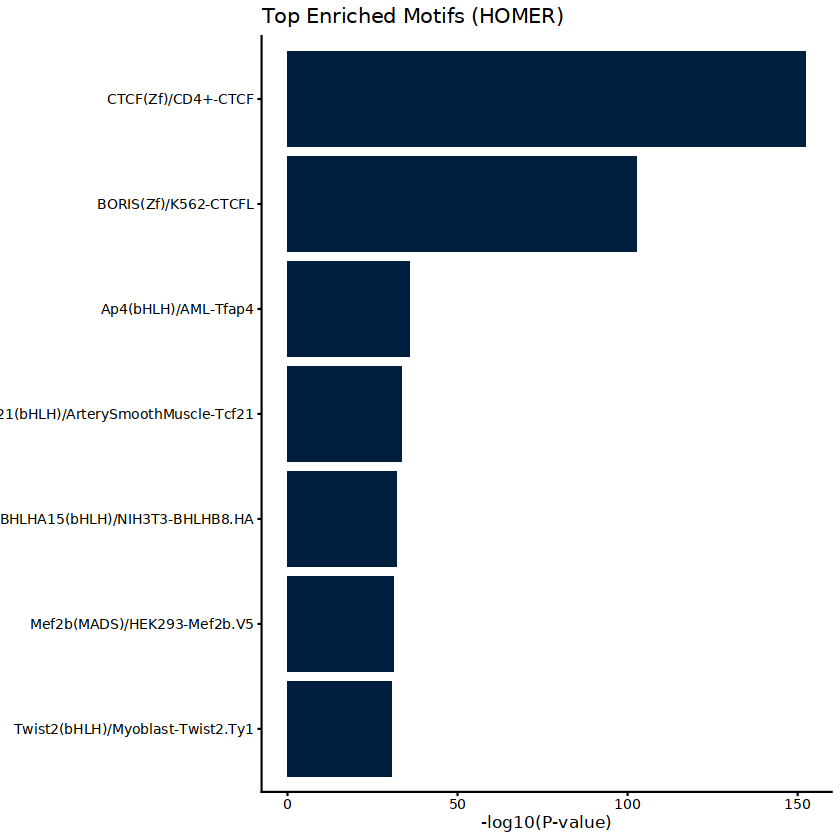

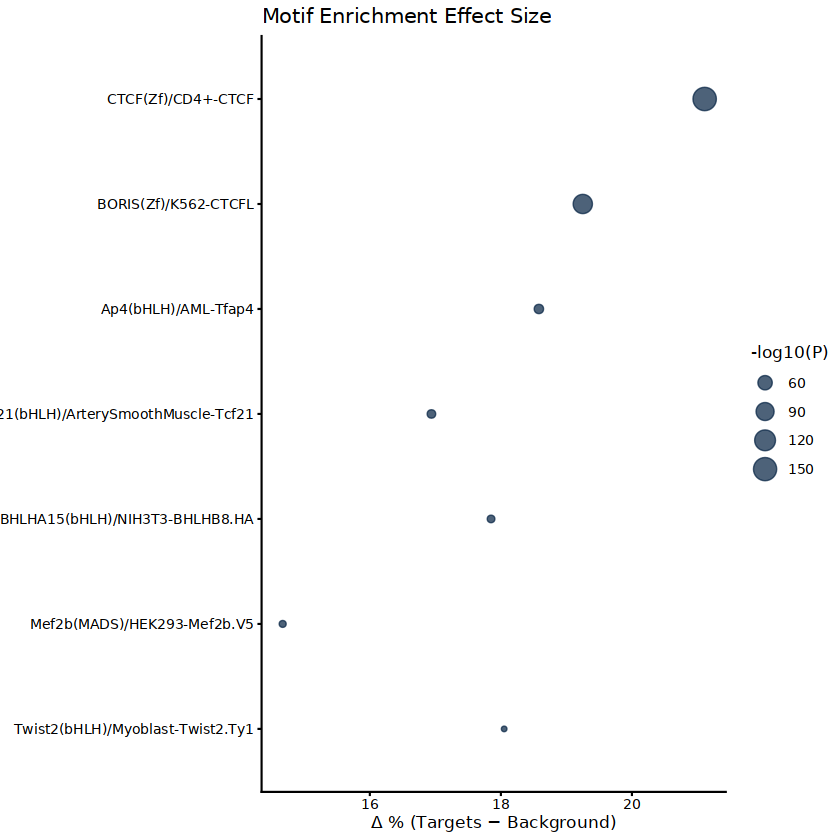

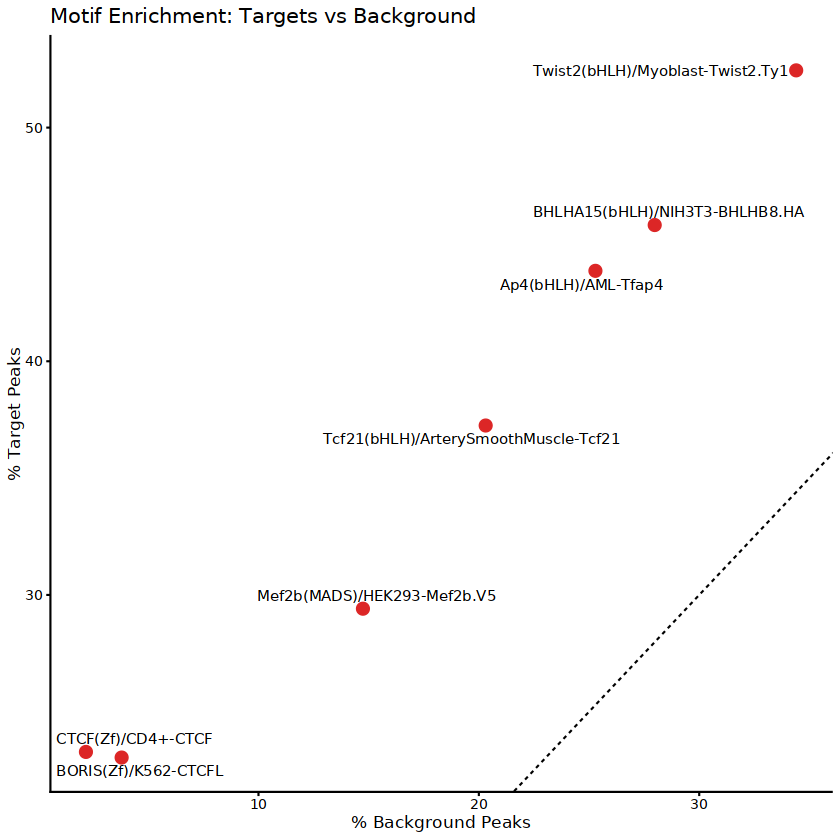

In [10]:
# TF Enrichment -- HOMER

# Homer command
#findMotifsGenome.pl /Aging/Data/Anderson/Multiomics/ATAC/ArchR/peaks/Anderson_PFC_AD_Inh_peaks_neg24_vs_all.diff_up_logFC_0.98.bed hg38 /Aging/Data/Anderson/Multiomics/ATAC/ArchR/peaks/Homer_Motif -size 500 -mask
#findMotifsGenome.pl /Aging/LQ_TACIT/aging_model/aging_pos_longevity_neg_intersect.bed hg38 /Aging/Data/Anderson/Multiomics/ATAC/ArchR/peaks/Homer_Motif_overlap/ -size 500 -mask

homer = read.csv(paste0(DATADIR,'peaks/Homer_Motif_overlap/knownResults.txt'), sep = "\t")
homer = homer[homer$P.value < 10^-30,]

homer = homer %>%
  rename(
    motif = 'Motif.Name',
    pval = 'P.value',
    logP = 'Log.P.value',
    pct_targets = 'X..of.Target.Sequences.with.Motif',
    pct_bg = 'X..of.Background.Sequences.with.Motif'
  ) %>%
  mutate(
    motif = sub("[--]ChIP-Seq.*$","",motif),
    neg_logP = as.numeric(logP)*(-1),
    pct_targets = as.numeric(gsub("%", "", pct_targets)),
    pct_bg = as.numeric(gsub("%", "", pct_bg))
  )
homer

#---------------------------------------------------------------------------------------------

# Manuscript Figure 9D --------------------------------------------------------
#------------------------------------------------------------------------------

#pdf(paste0(PLOTDIR, 'Anderson_AD_Inh_Neg24_Longevity_homer_knownResults.pdf'), width = 5, height = 1)

ggplot(homer, aes(x = reorder(motif, neg_logP), y = neg_logP)) +
  geom_col(fill = "#001F3F") +
  coord_flip() +
  labs(
    x = NULL,
    y = "-log10(P-value)",
    title = "Top Enriched Motifs (HOMER)"
  ) +
  theme_classic(base_size = 10)


ggplot(homer,
       aes(x = reorder(motif, neg_logP),
           y = pct_targets - pct_bg,
           size = neg_logP)) +
  geom_point(alpha = 0.7, color = "#001F3F") +
  coord_flip() +
  labs(
    x = NULL,
    y = "Δ % (Targets − Background)",
    size = "-log10(P)",
    title = "Motif Enrichment Effect Size"
  ) +
  theme_classic(base_size = 10)

ggplot(homer,
       aes(x = pct_bg, y = pct_targets, label = motif)) +
  geom_point(size = 3, color = "#DC2626") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  ggrepel::geom_text_repel(size = 3) +
  labs(
    x = "% Background Peaks",
    y = "% Target Peaks",
    title = "Motif Enrichment: Targets vs Background"
  ) +
  theme_classic(base_size = 10)

#dev.off()